In [7]:
import os
import pandas as pd
import numpy as np

# 定义可能的路径（自动兼容有无空格的情况）
path_options = [
    r'C:\Users\29429\Desktop\archive(1)', 
    r'C:\Users\29429\Desktop\archive (1)'
]

base_dir = None
for p in path_options:
    if os.path.exists(p):
        base_dir = p
        break

if base_dir:
    csv_path = os.path.join(base_dir, 'spam.csv')
    print(f"✅ 成功定位数据集: {csv_path}")
else:
    print("❌ 路径还是不对，请手动确认文件夹名字。")

# 加载数据
df = pd.read_csv(csv_path, encoding='latin-1')
df = df.iloc[:, [0, 1]] # 只取前两列
df.columns = ['label', 'text']
df['label'] = df['label'].map({'spam': 1, 'ham': 0}) # 标签转数字
print("数据加载成功，前5行如下：")
print(df.head())

✅ 成功定位数据集: C:\Users\29429\Desktop\archive(1)\spam.csv
数据加载成功，前5行如下：
   label                                               text
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...


In [9]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# 下载必要的资源
nltk.download('stopwords')
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # 1. 去掉非字母字符
    text = re.sub('[^a-zA-Z]', ' ', str(text))
    # 2. 转小写并切分
    text = text.lower().split()
    # 3. 提取词干并过滤停用词
    text = [ps.stem(word) for word in text if not word in stop_words]
    return ' '.join(text)

print("正在清洗文本，这可能需要几秒钟...")
df['clean_text'] = df['text'].apply(clean_text)
print("清洗完成！")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\29429\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


正在清洗文本，这可能需要几秒钟...
清洗完成！


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# 划分训练集和测试集 (80/20)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['clean_text'], df['label'], test_size=0.2, random_state=42
)

# 使用 TF-IDF 向量化
vectorizer = TfidfVectorizer(max_features=3000)
X_train = vectorizer.fit_transform(X_train_raw)
X_test = vectorizer.transform(X_test_raw)

print(f"特征提取完毕。训练集维度: {X_train.shape}")

特征提取完毕。训练集维度: (4457, 3000)


In [11]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

# 定义三个模型
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(solver='liblinear'),
    "SVM (Linear)": SVC(kernel='linear', probability=True)
}

print("--- 各模型 5 折交叉验证得分 ---")
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5)
    print(f"{name}: {scores.mean():.2%}")

# 最终选择最优模型（通常是 SVM）进行训练
final_model = SVC(kernel='linear', probability=True)
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

--- 各模型 5 折交叉验证得分 ---
Naive Bayes: 97.51%
Logistic Regression: 96.14%
SVM (Linear): 98.18%



测试集详细分类报告:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.98      0.87      0.92       150

    accuracy                           0.98      1115
   macro avg       0.98      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



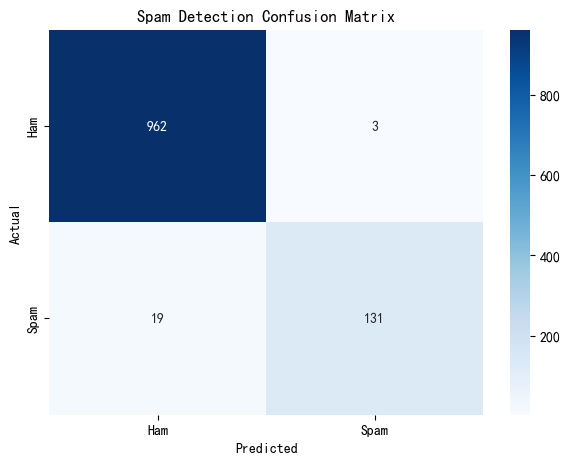

✅ 评估图表已保存至: C:\Users\29429\Desktop\archive(1)\final_report_img.png


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 打印文字报告
print("\n测试集详细分类报告:")
print(classification_report(y_test, y_pred))

# 绘制混淆矩阵
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title('Spam Detection Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# 保存图片到桌面文件夹
img_save_path = os.path.join(base_dir, 'final_report_img.png')
plt.savefig(img_save_path, dpi=300)
plt.show()
print(f"✅ 评估图表已保存至: {img_save_path}")

In [13]:
import joblib

model_file = os.path.join(base_dir, 'final_spam_model.pkl')
vec_file = os.path.join(base_dir, 'final_vectorizer.pkl')

joblib.dump(final_model, model_file)
joblib.dump(vectorizer, vec_file)

print(f"🚀 模型打包成功！\n文件1: {model_file}\n文件2: {vec_file}")

🚀 模型打包成功！
文件1: C:\Users\29429\Desktop\archive(1)\final_spam_model.pkl
文件2: C:\Users\29429\Desktop\archive(1)\final_vectorizer.pkl
